# Лабораторная работа 2 (вариант 1 seaborn-titanic)
## Визуальный анализ данных по пассажирам "Титаника" 👍 16/17

**тест [ссылка](https://forms.gle/SZCZeabauL1TPTLT8)**

dataset:

https://www.kaggle.com/datasets/nadezhda2019/titanic-train

**Подключим библиотеки.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Итак, разберемся в поставленной задаче: целевым столбцом является бинарный столбец Survived, в котором 0 означает, что пассажир погиб, а 1 - что пассажир выжил, нашей целью является проанализировать зависимость целевого признака от нецелевых, описанных ниже.

Нам даны
* id - номер пассажира,
* Pclass - класс, которым следовал пассажир (класс 1, класс 2 и класс 3),
* имя пассажира (Name),
* его пол (Gender),
* возраст (Age),
* SibSp - число братьев, сестер или супругов на борту у человека (максимум 8 братьев и сестер путешествовали вместе с одним из путешественников),
* Parch - количество родителей или детей, с которыми путешествовал каждый пассажир,
* номер билета (Ticket),
* тариф билета (Fare),
* номер каюты (Cabin),
* Embarked - информация о порте посадки пассажира. Есть три возможных значения для Embarked -  Саутгемптон, Шербург и Куинстаун.

**Считываем обучающую выборку.**

In [2]:
train_df = pd.read_csv("/kaggle/input/titanic-train/titanic_train.csv",
                       index_col='PassengerId')

In [3]:
train_df.head()

,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Посмотрим информацию по количеству непустых значений и типы данных.**

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Gender    891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


или так

In [5]:
train_df.isnull().sum()

Survived      0
Pclass        0
Name          0
Gender        0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

**Выведем описательную статистику.**

In [6]:
train_df.describe(include='int64') # object,  float

,Survived,Pclass,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.523008,0.381594
std,0.486592,0.836071,1.102743,0.806057
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000
50%,0.000000,3.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,0.000000
max,1.000000,3.000000,8.000000,6.000000


**Выбросим признак `Cabin`, потому что в нем очень много пропусков, а потом – все строки, где есть пропуски.**

In [7]:
train_df = train_df.drop('Cabin', axis=1).dropna()

In [8]:
len(train_df)

712

In [9]:
train_df.isnull().sum()

Survived    0
Pclass      0
Name        0
Gender      0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

# Решение теста

### 1. Какой части пассажиров удалось выжить? Посчитайте долю (в процентах) выживших пассажиров.

использовала Plotly

In [10]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "iframe"

live_data = train_df['Survived'].value_counts().reset_index()
live_data.columns = ['Survived', 'Count']
live_data['Survived'] = live_data['Survived'].map({0: 'погибших😢', 1: 'выживших😊'})

fig = px.pie(
    live_data,
    values='Count',
    names='Survived',
    title='<b>Круговая диаграмма при помощи Plotly (интерактивная, 1 вопрос теста)</b>'
)

fig.show()

### 2. Сколько мужчин / женщин находилось на борту?

столбчатая диаграмма bar plot, использовала метод plot с параметром kind=bar у Pandas

<Axes: title={'center': 'Пол, вопрос теста 2)'}, xlabel='Gender'>

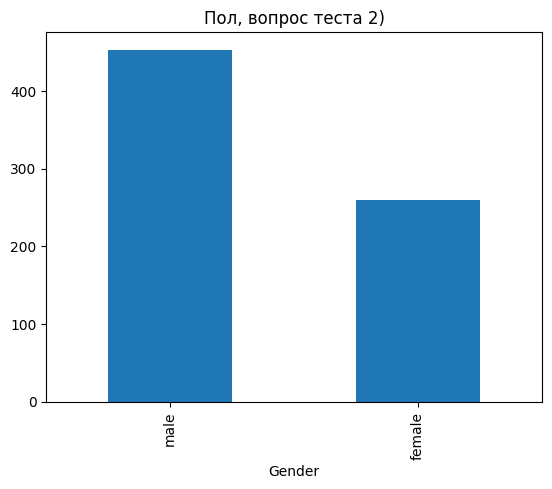

In [15]:
train_df['Gender'].value_counts().plot(kind='bar', title='Пол, вопрос теста 2)')

### 3. Какую долю (в процентах) пассажиры первого класса составляли среди всех пассажиров?

круговая диаграмма, использовала метод plot с параметром kind=pie у Pandas

<Axes: title={'center': 'Распределение по Классу, 3 вопрос теста'}, ylabel='count'>

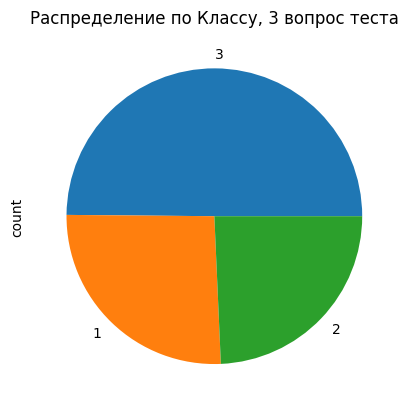

In [16]:
train_df['Pclass'].value_counts().plot(kind='pie', title='Распределение по Классу, 3 вопрос теста')

### 4. Какая группа пассажиров наиболее представлена?

использовала метод hist с параметром разбивки на 5

<Axes: >

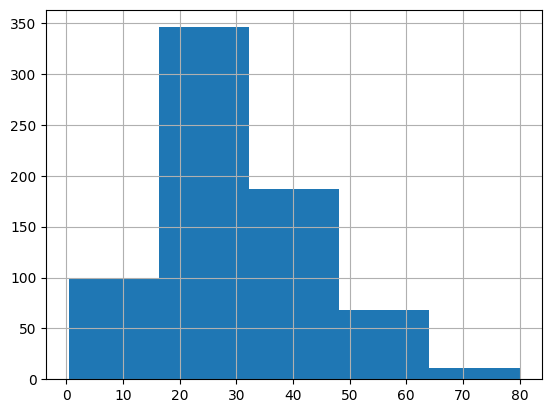

In [17]:
train_df["Age"].hist(bins=5) # Гистограмма при помощи .hist

### 5+6+13. 5)Высока ли корреляция между признаками Age и Fare? 6) Есть ли выбросы для признака Стоимость билета? 13) Чему равна корреляция между признаками Age и Fare?

комбинированный график jointplot, использовала Seaborn

в центре точечная диаграмм kind=scatter

по бокам гистограмма распределения

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Корреляции между возрастом и стоимостью билета нет, есть выбросы в стоимости билета Fare точки выше 500


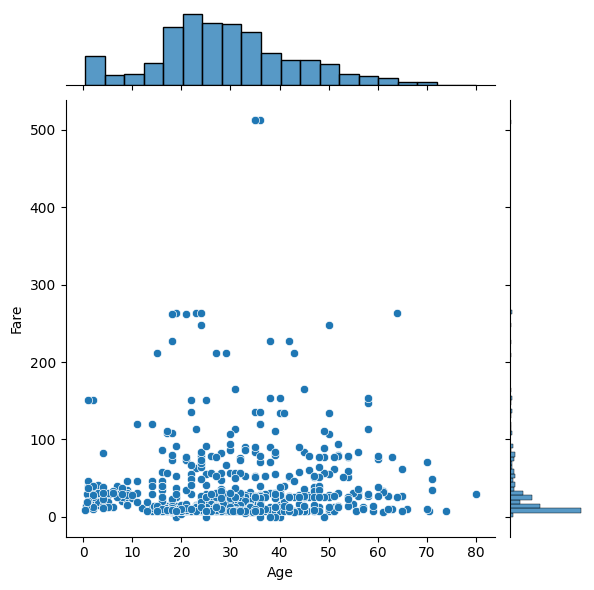

In [18]:
sns.jointplot(data=train_df, x='Age', y='Fare', kind='scatter') # Объединенный график при помощи Seaborn (5 и 6 и 13 вопрос теста)
print('Корреляции между возрастом и стоимостью билета нет, есть выбросы в стоимости билета Fare точки выше 500')

### 7. Правда ли, что женщины выживали чаще мужчин? Каковы доли выживших в обеих группах?

сгруппировала методом group_by, использовала столбчатую диаграмму kind=bar

In [19]:
train_df.head(2)

,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


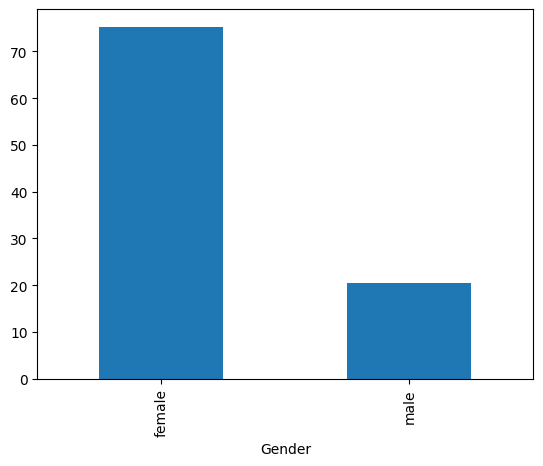

In [20]:
(train_df.groupby('Gender')['Survived'].mean() * 100).plot(kind='bar') # ответ на вопрос 7
plt.show()

### 8. Пассажиры какого класса выживали лучше всего?

сгруппировала методом group_by, использовала столбчатую диаграмму kind=bar

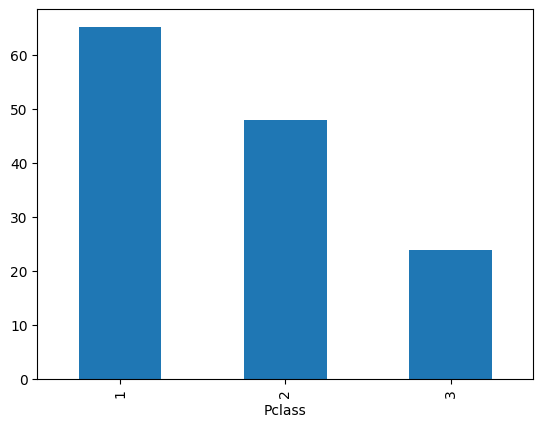

In [21]:
(train_df.groupby('Pclass')['Survived'].mean() * 100).plot(kind='bar') # ответ на вопрос 8
plt.show()

### 9. Среди женщин пассажирок 3 класса доля выживших составила примерно

использовала тепловую карту heatmap у Seaborn

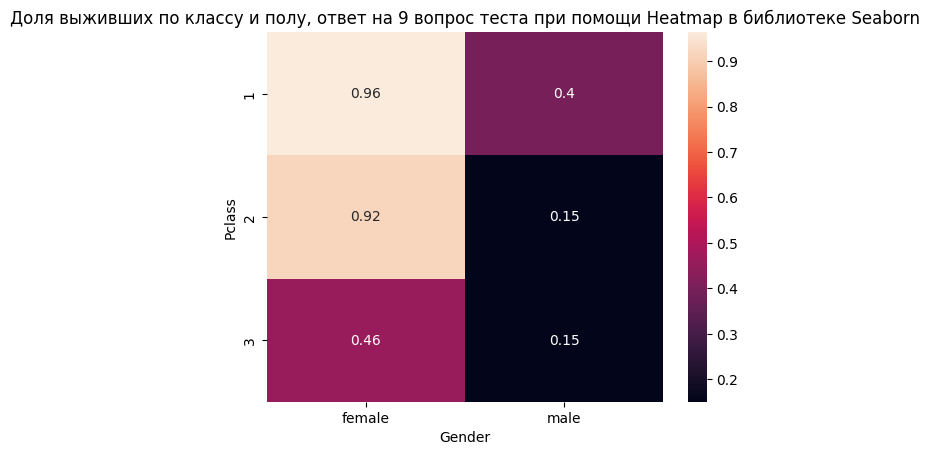

In [22]:
pivot_table = train_df.pivot_table(values='Survived',  # сводная таблица, взяла значение Выжили
                                   index='Pclass',      # взяла класс в строчку
                                   columns='Gender',      # взяла пол в колонку
                                   aggfunc='mean')        # агрегировала среднее значение

sns.heatmap(pivot_table, annot=True)
plt.title('Доля выживших по классу и полу, ответ на 9 вопрос теста при помощи Heatmap в библиотеке Seaborn')
plt.show()

### 10. Постройте график распределения выживания при делении пассажиров на 4 возрастные категории < 18; [18-30), [30-60), >=60 . Какая категория выживала лучше всего?

столбачатый график kind=bar

/tmp/ipykernel_36/1033975547.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Axes: title={'center': 'выжило больше детей'}, xlabel='AgeGroup'>

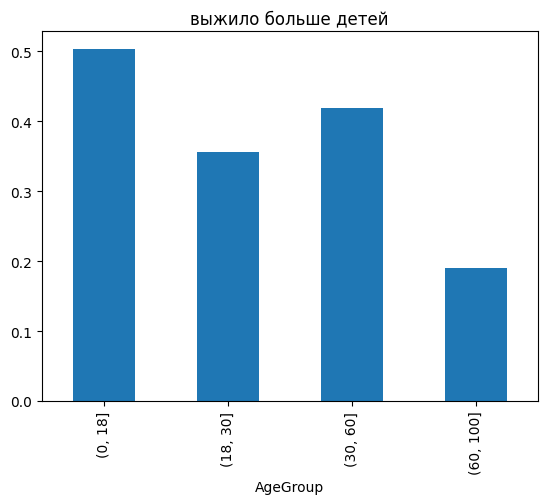

In [23]:
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins = [0, 18, 30, 60, 100]) # разделим по группам в отдельный столбик AgeGroup
train_df.groupby('AgeGroup')['Survived'].mean().plot(kind='bar', title='выжило больше детей') # группируем и рисуем столбачатый график (10 вопрос теста)

### 11. Какая доля пассажиров 1 класса моложе 30 лет выжила?

heatmap

/tmp/ipykernel_36/1073897674.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



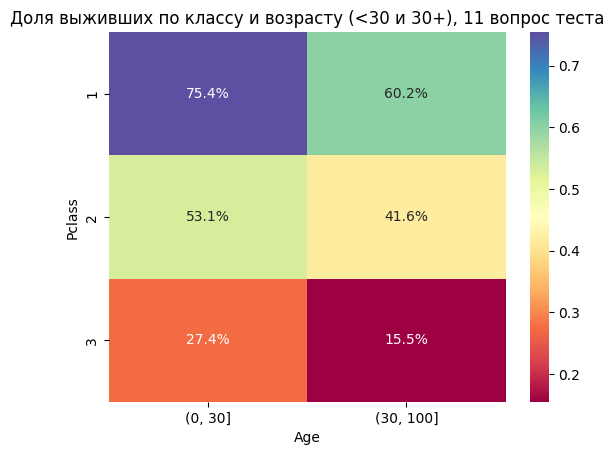

In [24]:
pivot_table = train_df.pivot_table(values='Survived', 
                                   index='Pclass', 
                                   columns=pd.cut(train_df['Age'], [0, 30, 100]), 
                                   aggfunc='mean')

sns.heatmap(pivot_table, annot=True, cmap='Spectral', fmt='.1%')
plt.title('Доля выживших по классу и возрасту (<30 и 30+), 11 вопрос теста')
plt.show()

### 12. Средняя стоимость билета для пассажиров от 5 до 30 лет максимальна в возрасте

kind='bar'

<Axes: title={'center': '11 лет = средняя цена билета выше, ответ на 12 вопрос'}, xlabel='Age'>

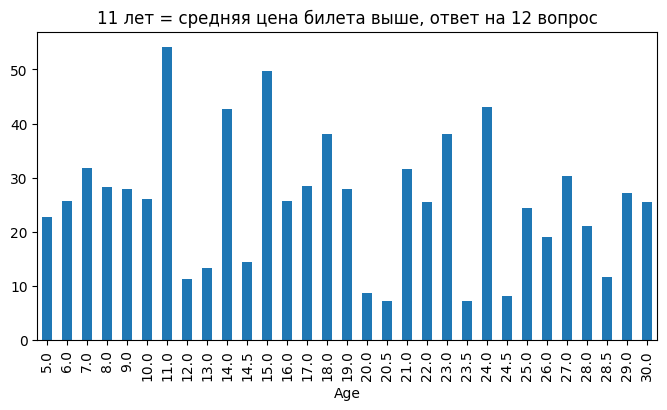

In [25]:
age_fare = train_df[(train_df['Age'] >= 5) & (train_df['Age'] <= 30)].groupby('Age')['Fare'].mean()

plt.figure(figsize=(8, 4))
age_fare.plot(kind='bar', title='11 лет = средняя цена билета выше, ответ на 12 вопрос')

### 14.  Сравните распределение возраста у спасенных и у погибших. Средний возраст погибших выше, верно?

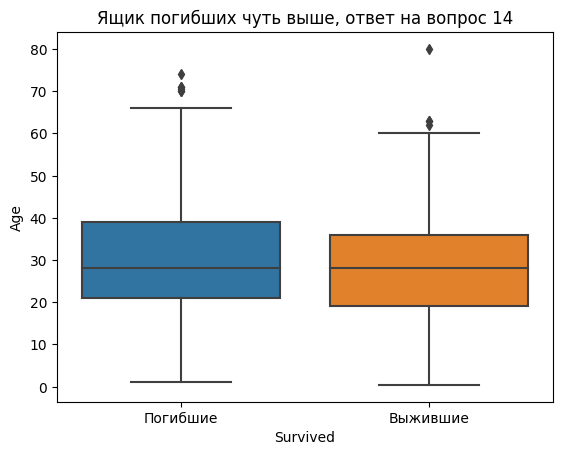

In [26]:
sns.boxplot(data=train_df, x='Survived', y='Age')
plt.xticks([0, 1], ['Погибшие', 'Выжившие'])
plt.title('Ящик погибших чуть выше, ответ на вопрос 14')
plt.show()

### 15. Как отличается средний возраст мужчин / женщин в зависимости от класса обслуживания? Выберите верные утверждения:

1)В среднем мужчины 1-го класса старше 40 лет

2)В среднем женщины 1-го класса старше 40 лет

3)Мужчины всех классов в среднем старше женщин того же класса

4)В среднем люди в 1 классе старше, чем во 2-ом, а те старше представителей 3-го класса

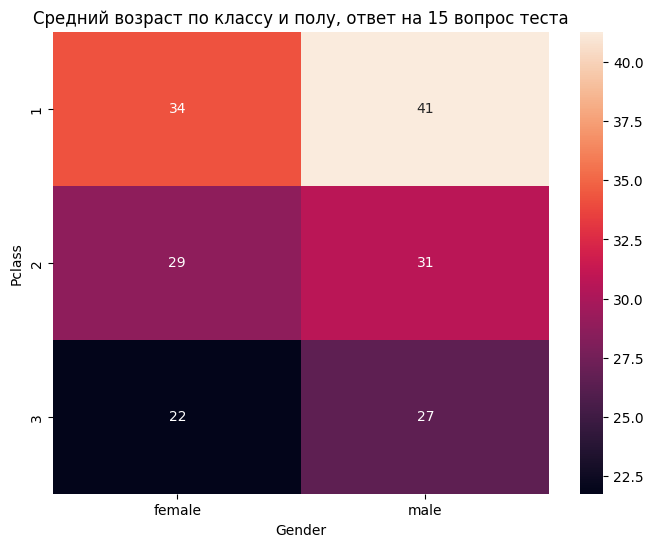

In [27]:
pivot_age = train_df.pivot_table(values='Age', 
                                index='Pclass', 
                                columns='Gender', 
                                aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_age, annot=True)
plt.title('Средний возраст по классу и полу, ответ на 15 вопрос теста')
plt.show()

### 16. Сколько было мужчин пассажиров 2-го класса?

<Axes: title={'center': '99мужчин 2 класса - ответ на 16 вопрос теста'}, xlabel='Gender'>

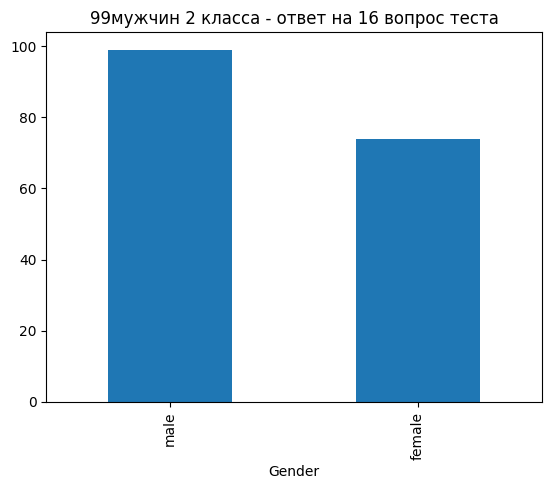

In [28]:
second_class = train_df[train_df['Pclass'] == 2]
second_class['Gender'].value_counts().plot(kind='bar', title='99мужчин 2 класса - ответ на 16 вопрос теста')

### 17. Найдите самое популярное имя среди пассажиров Титаника мужского пола?

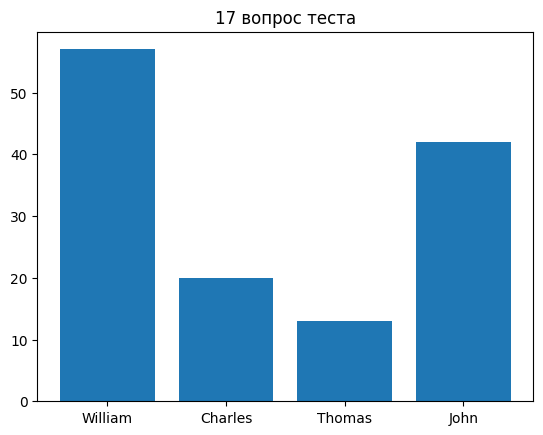

In [29]:
names = ['William', 'Charles', 'Thomas', 'John']
counts = [sum(train_df['Name'].str.contains(name)) for name in names]

plt.bar(names, counts)
plt.title('17 вопрос теста')
plt.show()